# Notebook 10 - Seller Performance & Delivery Analysis

## Objective
The goal of this notebook is to analyze seller performance and delivery efficiency in the Olist marketplace.

This notebook focuses on how sellers contribute to revenue and order volume, how delivery timelines vary across sellers and categories, and whether delivery delays are associated with lower customer review scores.

## Business Questions
This notebook answers questions such as:
- Which sellers generate the highest revenue and order volume?
- Which sellers have the worst late-delivery rates?
- Which product categories and states are most affected by delivery delays?
- Does late delivery reduce customer review scores?
- Which sellers are operationally risky despite strong sales?

## Business Value
This analysis helps the business:
- identify top-performing sellers
- detect sellers with poor delivery performance
- measure the impact of delays on customer satisfaction
- prioritize logistics and seller-management improvements
- build a seller scorecard for operational monitoring

## Notebook Scope
In this notebook, we will:
- merge orders, order items, sellers, reviews, products, and category data
- create delivery KPIs such as delivery time, estimated delivery time, delay days, and late-delivery flags
- evaluate seller revenue, freight cost, review score, and late-delivery rate
- analyze delay patterns by category and state
- identify strong sellers and operationally risky sellers
- summarize insights into business recommendations

In [17]:
# ======================================================
# Section 2 - Import Libraries
# ======================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os

import numpy as np
import pandas as pd

# If matplotlib is working, keep these imports.
# If not, comment them temporarily and continue the notebook.
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

In [18]:
# ======================================================
# Section 3 - Define Paths and Load Datasets
# ======================================================

DATA_DIR = Path(r"C:\Users\divya\Retail-Intelligence-Platform\data\raw")

orders_path = DATA_DIR / "olist_orders_dataset.csv"
order_items_path = DATA_DIR / "olist_order_items_dataset.csv"
sellers_path = DATA_DIR / "olist_sellers_dataset.csv"
reviews_path = DATA_DIR / "olist_order_reviews_dataset.csv"
products_path = DATA_DIR / "olist_products_dataset.csv"
category_translation_path = DATA_DIR / "product_category_name_translation.csv"
customers_path = DATA_DIR / "olist_customers_dataset.csv"

orders = pd.read_csv(orders_path)
order_items = pd.read_csv(order_items_path)
sellers = pd.read_csv(sellers_path)
reviews = pd.read_csv(reviews_path)
products = pd.read_csv(products_path)
category_translation = pd.read_csv(category_translation_path)
customers = pd.read_csv(customers_path)

print("Orders shape              :", orders.shape)
print("Order Items shape         :", order_items.shape)
print("Sellers shape             :", sellers.shape)
print("Reviews shape             :", reviews.shape)
print("Products shape            :", products.shape)
print("Category translation shape:", category_translation.shape)
print("Customers shape           :", customers.shape)

Orders shape              : (99441, 8)
Order Items shape         : (112650, 7)
Sellers shape             : (3095, 4)
Reviews shape             : (99224, 7)
Products shape            : (32951, 9)
Category translation shape: (71, 2)
Customers shape           : (99441, 5)


In [19]:
# ======================================================
# Section 4 - Inspect Columns
# ======================================================

print("Orders columns:")
print(orders.columns.tolist())

print("\nOrder Items columns:")
print(order_items.columns.tolist())

print("\nSellers columns:")
print(sellers.columns.tolist())

print("\nReviews columns:")
print(reviews.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nCategory translation columns:")
print(category_translation.columns.tolist())

print("\nCustomers columns:")
print(customers.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Order Items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Sellers columns:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

Reviews columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Products columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Category translation columns:
['product_category_name', 'product_category_name_english']

Customers columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'custo

In [20]:
# ======================================================
# Section 5 - Convert Date Columns
# ======================================================

order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

if "review_creation_date" in reviews.columns:
    reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")

if "review_answer_timestamp" in reviews.columns:
    reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")

print("Date conversion complete.")
display(orders[order_date_cols].head())

Date conversion complete.


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [21]:
# ======================================================
# Section 6 - Filter Delivered Orders
# ======================================================

orders_delivered = orders.loc[
    (orders["order_status"] == "delivered") &
    orders["order_purchase_timestamp"].notna() &
    orders["order_delivered_customer_date"].notna() &
    orders["order_estimated_delivery_date"].notna(),
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

print("Delivered orders shape:", orders_delivered.shape)
display(orders_delivered.head())

Delivered orders shape: (96470, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [22]:
# ======================================================
# Section 7 - Merge Orders with Order Items
# ======================================================

seller_base = orders_delivered.merge(
    order_items[
        ["order_id", "order_item_id", "product_id", "seller_id", "price", "freight_value", "shipping_limit_date"]
    ],
    on="order_id",
    how="inner"
)

print("Seller base shape after orders + order_items:", seller_base.shape)
display(seller_base.head())

Seller base shape after orders + order_items: (110189, 14)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,price,freight_value,shipping_limit_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2017-10-06 11:07:15
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,2018-07-30 03:24:27
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,2018-08-13 08:55:23
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,2017-11-23 19:45:59
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,2018-02-19 20:31:37


In [23]:
# ======================================================
# Section 8 - Merge Seller Information
# ======================================================

seller_base = seller_base.merge(
    sellers[["seller_id", "seller_zip_code_prefix", "seller_city", "seller_state"]],
    on="seller_id",
    how="left"
)

print("Seller base shape after seller merge:", seller_base.shape)
display(seller_base.head())

Seller base shape after seller merge: (110189, 17)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,price,freight_value,shipping_limit_date,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2017-10-06 11:07:15,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,2018-07-30 03:24:27,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,2018-08-13 08:55:23,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,2017-11-23 19:45:59,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,2018-02-19 20:31:37,8752,mogi das cruzes,SP


In [24]:
# ======================================================
# Section 9 - Merge Review Scores
# ======================================================

review_cols = ["order_id", "review_score"]

seller_base = seller_base.merge(
    reviews[review_cols],
    on="order_id",
    how="left"
)

print("Seller base shape after review merge:", seller_base.shape)
display(seller_base.head())

Seller base shape after review merge: (110832, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,price,freight_value,shipping_limit_date,seller_zip_code_prefix,seller_city,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2017-10-06 11:07:15,9350,maua,SP,4.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,2018-07-30 03:24:27,31570,belo horizonte,SP,4.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,2018-08-13 08:55:23,14840,guariba,SP,5.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,2017-11-23 19:45:59,31842,belo horizonte,MG,5.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,2018-02-19 20:31:37,8752,mogi das cruzes,SP,5.00


In [25]:
# ======================================================
# Section 10 - Merge Products and Category Translation
# ======================================================

seller_base = seller_base.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

seller_base = seller_base.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

seller_base["category_final"] = seller_base["product_category_name_english"].fillna(
    seller_base["product_category_name"]
)

print("Seller base shape after product/category merge:", seller_base.shape)
display(
    seller_base[
        ["order_id", "seller_id", "product_id", "product_category_name", "product_category_name_english", "category_final"]
    ].head()
)

Seller base shape after product/category merge: (110832, 21)


,order_id,seller_id,product_id,product_category_name,product_category_name_english,category_final
0,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,utilidades_domesticas,housewares,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,perfumaria,perfumery,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,automotivo,auto,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,66922902710d126a0e7d26b0e3805106,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,2c9e548be18521d1c43cde1c582c6de8,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,stationery,stationery


In [26]:
# ======================================================
# Section 11 - Merge Customer State
# ======================================================

seller_base = seller_base.merge(
    customers[["customer_id", "customer_city", "customer_state"]],
    on="customer_id",
    how="left"
)

print("Seller base shape after customer merge:", seller_base.shape)
display(seller_base.head())

Seller base shape after customer merge: (110832, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,price,freight_value,shipping_limit_date,seller_zip_code_prefix,seller_city,seller_state,review_score,product_category_name,product_category_name_english,category_final,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2017-10-06 11:07:15,9350,maua,SP,4.00,utilidades_domesticas,housewares,housewares,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,2018-07-30 03:24:27,31570,belo horizonte,SP,4.00,perfumaria,perfumery,perfumery,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,2018-08-13 08:55:23,14840,guariba,SP,5.00,automotivo,auto,auto,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,2017-11-23 19:45:59,31842,belo horizonte,MG,5.00,pet_shop,pet_shop,pet_shop,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,2018-02-19 20:31:37,8752,mogi das cruzes,SP,5.00,papelaria,stationery,stationery,santo andre,SP


In [27]:
# ======================================================
# Section 12 - Create Delivery KPI Fields
# ======================================================

# Delivery time from purchase to actual customer delivery
seller_base["delivery_days"] = (
    seller_base["order_delivered_customer_date"] - seller_base["order_purchase_timestamp"]
).dt.days

# Estimated delivery time from purchase to promised date
seller_base["estimated_delivery_days"] = (
    seller_base["order_estimated_delivery_date"] - seller_base["order_purchase_timestamp"]
).dt.days

# Delay relative to promised date
seller_base["delay_days"] = (
    seller_base["order_delivered_customer_date"] - seller_base["order_estimated_delivery_date"]
).dt.days

# Seller handling time: approval to carrier handoff
seller_base["seller_handoff_days"] = (
    seller_base["order_delivered_carrier_date"] - seller_base["order_approved_at"]
).dt.days

# Late delivery flag
seller_base["is_late"] = np.where(seller_base["delay_days"] > 0, 1, 0)

display(
    seller_base[
        [
            "order_id", "seller_id", "delivery_days", "estimated_delivery_days",
            "delay_days", "seller_handoff_days", "is_late"
        ]
    ].head()
)

,order_id,seller_id,delivery_days,estimated_delivery_days,delay_days,seller_handoff_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,8,15,-8,2.00,0
1,53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,13,19,-6,0.00,0
2,47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,9,26,-18,0.00,0
3,949d5b44dbf5de918fe9c16f97b45f8a,66922902710d126a0e7d26b0e3805106,13,26,-13,3.00,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2c9e548be18521d1c43cde1c582c6de8,2,12,-10,0.00,0


In [28]:
# ======================================================
# Section 13 - Overall Delivery KPI Summary
# FINAL KPI-ALIGNED VERSION
# ======================================================

if "seller_base" not in globals():
    raise ValueError("seller_base dataframe not found. Run the seller base creation steps first.")

late_orders_only = seller_base.loc[seller_base["is_late"] == 1].copy()

delivery_kpi_summary = pd.DataFrame({
    "Total Orders": [seller_base["order_id"].nunique()],
    "Total Sellers": [seller_base["seller_id"].nunique()],
    "Average Delivery Days": [seller_base["delivery_days"].mean()],
    "Average Estimated Delivery Days": [seller_base["estimated_delivery_days"].mean()],
    "Average Delivery Variance Days": [seller_base["delay_days"].mean()],   # negative = early, positive = late
    "Late Delivery Rate (%)": [seller_base["is_late"].mean() * 100],
    "Average Late Delay Days": [late_orders_only["delay_days"].mean()],
    "Average Review Score": [seller_base["review_score"].mean()]
})

delivery_kpi_summary = delivery_kpi_summary.round({
    "Average Delivery Days": 2,
    "Average Estimated Delivery Days": 2,
    "Average Delivery Variance Days": 2,
    "Late Delivery Rate (%)": 2,
    "Average Late Delay Days": 2,
    "Average Review Score": 2
})

display(delivery_kpi_summary)

# ------------------------------------------------------
# Export delivery KPI summary for Streamlit / Power BI
# ------------------------------------------------------
OUTPUT_DIR = Path(r"C:\Users\divya")
delivery_kpi_output_file = OUTPUT_DIR / "delivery_kpi_summary.csv"

delivery_kpi_summary.to_csv(delivery_kpi_output_file, index=False, encoding="utf-8")

print(f"\nSaved successfully to: {delivery_kpi_output_file}")

,Total Orders,Total Sellers,Average Delivery Days,Average Estimated Delivery Days,Average Delivery Variance Days,Late Delivery Rate (%),Average Late Delay Days,Average Review Score
0,96470,2970,12.01,23.45,-12.03,6.58,10.49,4.08



Saved successfully to: C:\Users\divya\delivery_kpi_summary.csv


In [29]:
# ======================================================
# Section 14 - Seller Performance Summary
# FINAL KPI-ALIGNED VERSION
# ======================================================

if "seller_base" not in globals():
    raise ValueError("seller_base dataframe not found. Run the seller base creation steps first.")

seller_summary = (
    seller_base.groupby("seller_id")
    .agg(
        Orders=("order_id", "nunique"),
        Items=("order_item_id", "count"),
        Revenue=("price", "sum"),
        Freight=("freight_value", "sum"),
        Avg_Review=("review_score", "mean"),
        Avg_Delivery_Days=("delivery_days", "mean"),
        Avg_Delay_Days=("delay_days", "mean"),
        Late_Delivery_Rate=("is_late", "mean"),
        Avg_Seller_Handoff_Days=("seller_handoff_days", "mean")
    )
    .reset_index()
)

seller_summary["Late_Delivery_Rate"] = seller_summary["Late_Delivery_Rate"] * 100

# Optional seller location enrichment if columns exist in seller_base
seller_location = None
location_cols = ["seller_id", "seller_city", "seller_state"]
if all(col in seller_base.columns for col in location_cols):
    seller_location = (
        seller_base[location_cols]
        .drop_duplicates(subset=["seller_id"])
        .copy()
    )
    seller_summary = seller_summary.merge(
        seller_location,
        on="seller_id",
        how="left"
    )

display(seller_summary.head())

# ------------------------------------------------------
# Build seller KPI summary for shared dashboard KPIs
# ------------------------------------------------------
seller_kpi_summary = pd.DataFrame({
    "total_sellers": [seller_summary["seller_id"].nunique()],
    "seller_revenue": [seller_summary["Revenue"].sum()],
    "avg_revenue_per_seller": [seller_summary["Revenue"].mean()],
    "avg_orders_per_seller": [seller_summary["Orders"].mean()],
    "avg_seller_review_score": [seller_summary["Avg_Review"].mean()],
    "top_seller_revenue": [seller_summary["Revenue"].max()]
})

seller_kpi_summary = seller_kpi_summary.round({
    "seller_revenue": 2,
    "avg_revenue_per_seller": 2,
    "avg_orders_per_seller": 2,
    "avg_seller_review_score": 2,
    "top_seller_revenue": 2
})

# ------------------------------------------------------
# Export both seller summary and seller KPI summary
# ------------------------------------------------------
OUTPUT_DIR = Path(r"C:\Users\divya")

seller_summary_output_file = OUTPUT_DIR / "seller_performance_summary.csv"
seller_kpi_output_file = OUTPUT_DIR / "seller_kpi_summary.csv"

seller_summary.to_csv(seller_summary_output_file, index=False, encoding="utf-8")
seller_kpi_summary.to_csv(seller_kpi_output_file, index=False, encoding="utf-8")

print("\nSeller summary shape:", seller_summary.shape)
print("Seller summary columns:", seller_summary.columns.tolist())

print("\nSeller KPI summary:")
display(seller_kpi_summary)

print(f"\nSaved successfully to: {seller_summary_output_file}")
print(f"Saved successfully to: {seller_kpi_output_file}")

,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,"2,685.00",63.06,3.67,10.33,-16.33,0.00,2.33,santo andre,SP
1,001cca7ae9ae17fb1caed9dfb1094831,195,234,"24,487.03","8,655.87",3.97,12.63,-13.21,5.13,1.68,cariacica,ES
2,002100f778ceb8431b7a1020ff7ab48f,50,55,"1,236.50",791.35,4.04,15.64,-8.22,16.36,2.98,franca,SP
3,003554e2dce176b5555353e4f3555ac8,1,1,120.00,19.38,5.00,4.00,-27.00,0.00,0.00,goiania,GO
4,004c9cd9d87a3c30c522c48c4fc07416,156,174,"20,324.20","3,632.04",4.15,14.33,-11.61,6.90,0.94,ibitinga,SP



Seller summary shape: (2970, 12)
Seller summary columns: ['seller_id', 'Orders', 'Items', 'Revenue', 'Freight', 'Avg_Review', 'Avg_Delivery_Days', 'Avg_Delay_Days', 'Late_Delivery_Rate', 'Avg_Seller_Handoff_Days', 'seller_city', 'seller_state']

Seller KPI summary:


,total_sellers,seller_revenue,avg_revenue_per_seller,avg_orders_per_seller,avg_seller_review_score,top_seller_revenue
0,2970,"13,278,587.41","4,470.90",32.93,4.15,"226,987.93"



Saved successfully to: C:\Users\divya\seller_performance_summary.csv
Saved successfully to: C:\Users\divya\seller_kpi_summary.csv


In [30]:
# ======================================================
# Section 15 - Add Seller Location to Summary
# ======================================================

seller_summary = seller_summary.merge(
    sellers[["seller_id", "seller_city", "seller_state"]],
    on="seller_id",
    how="left"
)

display(seller_summary.head())

,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city_x,seller_state_x,seller_city_y,seller_state_y
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,"2,685.00",63.06,3.67,10.33,-16.33,0.00,2.33,santo andre,SP,santo andre,SP
1,001cca7ae9ae17fb1caed9dfb1094831,195,234,"24,487.03","8,655.87",3.97,12.63,-13.21,5.13,1.68,cariacica,ES,cariacica,ES
2,002100f778ceb8431b7a1020ff7ab48f,50,55,"1,236.50",791.35,4.04,15.64,-8.22,16.36,2.98,franca,SP,franca,SP
3,003554e2dce176b5555353e4f3555ac8,1,1,120.00,19.38,5.00,4.00,-27.00,0.00,0.00,goiania,GO,goiania,GO
4,004c9cd9d87a3c30c522c48c4fc07416,156,174,"20,324.20","3,632.04",4.15,14.33,-11.61,6.90,0.94,ibitinga,SP,ibitinga,SP


,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city_x,seller_state_x,seller_city_y,seller_state_y
834,4869f7a5dfa277a7dca6462dcf3b52b2,1124,1148,"226,987.93","20,019.13",4.14,14.55,-11.16,10.54,1.81,guariba,SP,guariba,SP
982,53243585a1d6dc2643021fd1853d8905,348,400,"217,940.44","12,856.58",4.13,12.94,-11.61,3.00,2.69,lauro de freitas,BA,lauro de freitas,BA
858,4a3ca9315b744ce9f8e9374361493884,1772,1971,"199,408.32","34,712.46",3.83,13.93,-9.66,9.69,1.85,ibitinga,SP,ibitinga,SP
2903,fa1c13f2614d7b5c4749cbc52fecda94,578,579,"190,917.14","9,916.36",4.37,12.84,-10.31,9.15,1.84,sumare,SP,sumare,SP
1480,7c67e1448b00f6e969d365cea6b010ab,973,1366,"188,063.83","51,581.24",3.35,21.94,-11.50,8.86,11.05,itaquaquecetuba,SP,itaquaquecetuba,SP
1504,7e93a43ef30c4f03f38b393420bc753a,319,322,"165,981.49","5,992.06",4.36,10.83,-12.16,4.66,1.92,barueri,SP,barueri,SP
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311,1571,"162,303.67","25,273.30",4.08,10.71,-11.31,6.37,1.78,piracicaba,SP,piracicaba,SP
1450,7a67c85e85bb2ce8582c35f2203ad736,1145,1159,"140,238.65","20,670.27",4.27,10.67,-11.84,5.18,1.09,sao paulo,SP,sao paulo,SP
188,1025f0e2d44d7041d6cf58b6550e0bfa,910,1434,"139,720.16","34,006.83",3.87,11.53,-11.13,6.62,3.20,sao paulo,SP,sao paulo,SP
1758,955fee9216a65b617aa5c0531780ce60,1261,1474,"131,906.71","24,791.95",4.09,10.29,-10.33,6.45,1.21,sao paulo,SP,sao paulo,SP


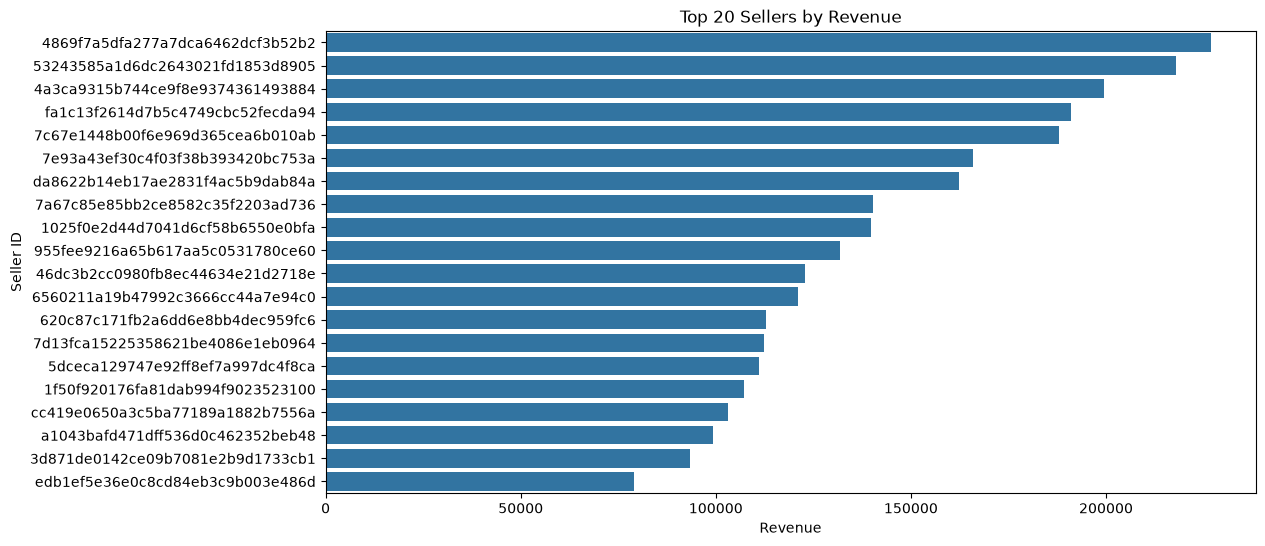

In [31]:
# ======================================================
# Section 16 - Top Sellers by Revenue
# ======================================================

top_sellers_revenue = seller_summary.sort_values("Revenue", ascending=False).head(20)
display(top_sellers_revenue)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_sellers_revenue, x="Revenue", y="seller_id")
plt.title("Top 20 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.show()

,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city_x,seller_state_x,seller_city_y,seller_state_y
1190,6560211a19b47992c3666cc44a7e94c0,1819,2002,"120,983.82","27,437.48",3.95,9.07,-11.72,5.14,0.69,sao paulo,SP,sao paulo,SP
858,4a3ca9315b744ce9f8e9374361493884,1772,1971,"199,408.32","34,712.46",3.83,13.93,-9.66,9.69,1.85,ibitinga,SP,ibitinga,SP
2388,cc419e0650a3c5ba77189a1882b7556a,1651,1759,"103,152.56","25,438.39",4.15,11.09,-13.03,5.12,1.88,santo andre,SP,santo andre,SP
358,1f50f920176fa81dab994f9023523100,1399,1935,"107,147.91","35,217.08",3.99,15.11,-10.83,7.80,2.88,sao jose do rio preto,SP,sao jose do rio preto,SP
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311,1571,"162,303.67","25,273.30",4.08,10.71,-11.31,6.37,1.78,piracicaba,SP,piracicaba,SP
1758,955fee9216a65b617aa5c0531780ce60,1261,1474,"131,906.71","24,791.95",4.09,10.29,-10.33,6.45,1.21,sao paulo,SP,sao paulo,SP
1450,7a67c85e85bb2ce8582c35f2203ad736,1145,1159,"140,238.65","20,670.27",4.27,10.67,-11.84,5.18,1.09,sao paulo,SP,sao paulo,SP
2725,ea8482cd71df3c1969d7b9473ff13abc,1132,1188,"36,696.76","17,291.87",3.98,12.85,-10.12,8.42,2.38,sao paulo,SP,sao paulo,SP
834,4869f7a5dfa277a7dca6462dcf3b52b2,1124,1148,"226,987.93","20,019.13",4.14,14.55,-11.16,10.54,1.81,guariba,SP,guariba,SP
712,3d871de0142ce09b7081e2b9d1733cb1,1064,1132,"93,456.40","22,121.04",4.15,12.95,-13.11,5.48,2.48,campo limpo paulista,SP,campo limpo paulista,SP


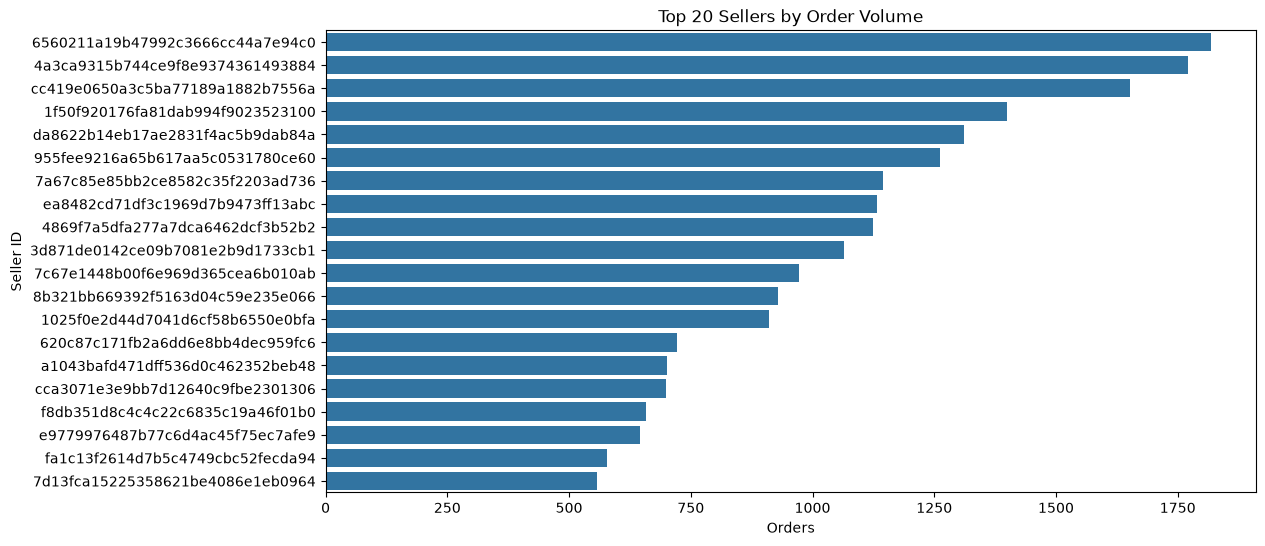

In [32]:
# ======================================================
# Section 17 - Top Sellers by Orders
# ======================================================

top_sellers_orders = seller_summary.sort_values("Orders", ascending=False).head(20)
display(top_sellers_orders)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_sellers_orders, x="Orders", y="seller_id")
plt.title("Top 20 Sellers by Order Volume")
plt.xlabel("Orders")
plt.ylabel("Seller ID")
plt.show()

In [33]:
# ======================================================
# Section 18 - Sellers with Highest Late Delivery Rate
# ======================================================

MIN_SELLER_ORDERS = 20

seller_delay_rank = seller_summary.loc[
    seller_summary["Orders"] >= MIN_SELLER_ORDERS
].sort_values("Late_Delivery_Rate", ascending=False)

display(seller_delay_rank.head(20))

,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city_x,seller_state_x,seller_city_y,seller_state_y
451,2709af9587499e95e803a6498a5a56e9,25,46,"1,180.56",549.73,2.60,11.93,-4.48,50.00,1.72,sao paulo,SP,sao paulo,SP
1000,54965bbe3e4f07ae045b90b0b8541f52,73,81,"10,351.70","2,076.26",3.07,26.23,-2.40,32.10,15.12,foz do iguacu,PR,foz do iguacu,PR
1543,821fb029fc6e495ca4f08a35d51e53a5,24,25,"17,851.62","1,365.55",3.50,15.96,-4.88,32.00,1.00,sao paulo,SP,sao paulo,SP
2766,ede0c03645598cdfc63ca8237acbe73d,43,47,"2,352.15",708.30,3.67,18.04,-4.19,31.91,3.02,ribeirao preto,SP,ribeirao preto,SP
2011,ad781527c93d00d89a11eecd9dcad7c1,38,38,"6,039.63","2,173.49",3.34,25.03,-9.08,31.58,10.53,sao jose do rio preto,SP,sao jose do rio preto,SP
1509,7f152321c60a266edc53af1925ef96c1,20,20,"3,919.80",552.12,3.80,23.10,-6.40,30.00,3.15,criciuma,SC,criciuma,SC
478,2a1348e9addc1af5aaa619b1a3679d6b,48,51,"2,697.40",727.37,3.04,26.78,0.71,29.41,4.25,belo horizonte,MG,belo horizonte,MG
2873,f76a3b1349b6df1ee875d1f3fa4340f0,24,24,"4,160.79",588.19,3.46,16.67,-5.54,29.17,7.67,sao paulo,SP,sao paulo,SP
57,054694fa03fe82cec4b7551487331d74,20,21,"8,286.10",660.24,3.29,29.71,-1.95,28.57,8.71,itajobi,SP,itajobi,SP
1556,835f0f7810c76831d6c7d24c7a646d4d,42,48,"4,990.20",932.05,3.31,18.04,-5.67,27.08,8.62,sao paulo,SP,sao paulo,SP


In [34]:
# ======================================================
# Section 19 - Sellers with Lowest Review Scores
# ======================================================

seller_review_rank = seller_summary.loc[
    seller_summary["Orders"] >= MIN_SELLER_ORDERS
].sort_values("Avg_Review", ascending=True)

display(seller_review_rank.head(20))

,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city_x,seller_state_x,seller_city_y,seller_state_y
323,1ca7077d890b907f89be8c954a02686a,108,127,"12,474.64","1,522.01",2.27,14.51,-6.86,14.96,4.63,santana de parnaiba,SP,santana de parnaiba,SP
451,2709af9587499e95e803a6498a5a56e9,25,46,"1,180.56",549.73,2.60,11.93,-4.48,50.00,1.72,sao paulo,SP,sao paulo,SP
540,2eb70248d66e0e3ef83659f71b244378,187,198,"39,115.62","3,063.75",2.81,17.51,-10.08,11.62,10.14,campinas,SP,campinas,SP
1779,972d0f9cf61b499a4812cf0bfa3ad3c4,81,86,"7,910.42","2,100.73",2.96,17.76,-9.76,11.63,4.07,brusque,SC,brusque,SC
1928,a49928bcdf77c55c6d6e05e09a9b4ca5,96,104,"8,646.90","1,726.92",2.97,16.52,-4.59,21.15,6.28,sao paulo,SP,sao paulo,SP
1139,602044f2c16190c2c6e45eb35c2e21cb,48,58,"3,739.14",952.02,3.00,15.45,-7.81,18.97,1.07,ibitinga,SP,ibitinga,SP
1683,8e6d7754bc7e0f22c96d255ebda59eba,84,132,"14,346.57","1,724.19",3.03,13.61,-6.30,9.85,4.65,sao jose dos campos,SP,sao jose dos campos,SP
478,2a1348e9addc1af5aaa619b1a3679d6b,48,51,"2,697.40",727.37,3.04,26.78,0.71,29.41,4.25,belo horizonte,MG,belo horizonte,MG
2171,bbad7e518d7af88a0897397ffdca1979,68,84,"4,426.32","1,314.92",3.05,14.79,-7.02,22.62,5.27,sao paulo,SP,sao paulo,SP
1000,54965bbe3e4f07ae045b90b0b8541f52,73,81,"10,351.70","2,076.26",3.07,26.23,-2.40,32.10,15.12,foz do iguacu,PR,foz do iguacu,PR


,seller_id,Orders,Revenue,Avg_Delay_Days,Late_Delivery_Rate,Avg_Review
1,001cca7ae9ae17fb1caed9dfb1094831,195,"24,487.03",-13.21,5.13,3.97
2,002100f778ceb8431b7a1020ff7ab48f,50,"1,236.50",-8.22,16.36,4.04
4,004c9cd9d87a3c30c522c48c4fc07416,156,"20,324.20",-11.61,6.90,4.15
8,00ee68308b45bc5e2660cd833c3f81cc,135,"20,345.00",-10.87,6.36,4.33
9,00fc707aaaad2d31347cf883cd2dfe10,103,"13,409.90",-15.57,3.52,3.74


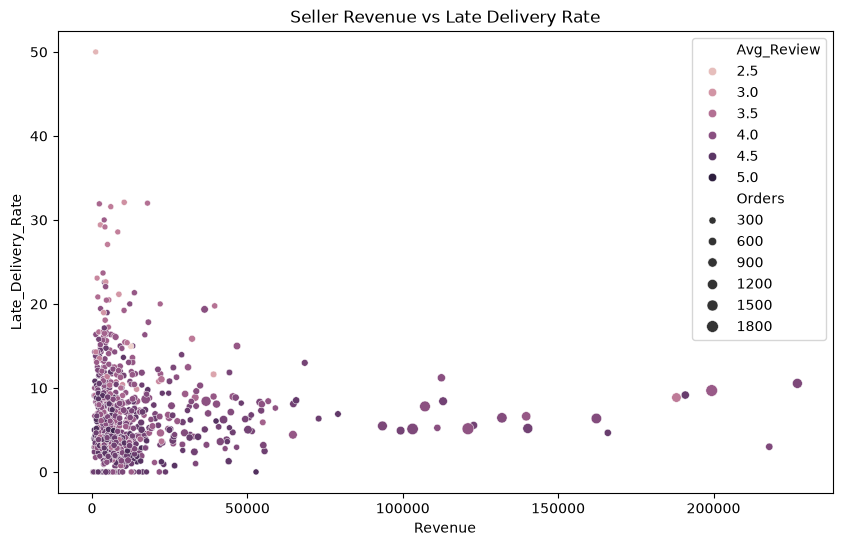

In [35]:
# ======================================================
# Section 20 - Revenue vs Delay Analysis
# ======================================================

seller_perf_view = seller_summary.loc[
    seller_summary["Orders"] >= MIN_SELLER_ORDERS
].copy()

display(
    seller_perf_view[
        ["seller_id", "Orders", "Revenue", "Avg_Delay_Days", "Late_Delivery_Rate", "Avg_Review"]
    ].head()
)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=seller_perf_view,
    x="Revenue",
    y="Late_Delivery_Rate",
    size="Orders",
    hue="Avg_Review"
)
plt.title("Seller Revenue vs Late Delivery Rate")
plt.show()

,is_late,review_score,Delivery_Status
0,0,4.21,On Time / Early
1,1,2.26,Late


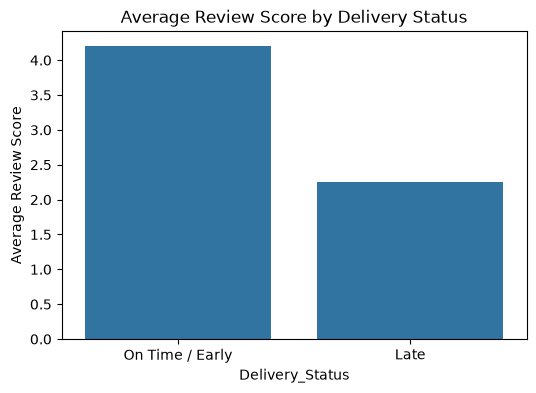

In [36]:
# ======================================================
# Section 21 - Review Score vs Late Delivery
# ======================================================

review_by_late = (
    seller_base.groupby("is_late")["review_score"]
    .mean()
    .reset_index()
)

review_by_late["Delivery_Status"] = review_by_late["is_late"].map({0: "On Time / Early", 1: "Late"})
display(review_by_late)
plt.figure(figsize=(6, 4))
sns.barplot(data=review_by_late, x="Delivery_Status", y="review_score")
plt.title("Average Review Score by Delivery Status")
plt.ylabel("Average Review Score")
plt.show()

In [37]:
# ======================================================
# Section 22 - Category-Level Delivery Analysis
# ======================================================

category_delivery = (
    seller_base.groupby("category_final")
    .agg(
        Orders=("order_id", "nunique"),
        Revenue=("price", "sum"),
        Avg_Delivery_Days=("delivery_days", "mean"),
        Avg_Delay_Days=("delay_days", "mean"),
        Late_Delivery_Rate=("is_late", "mean"),
        Avg_Review=("review_score", "mean")
    )
    .reset_index()
)

category_delivery["Late_Delivery_Rate"] = category_delivery["Late_Delivery_Rate"] * 100

category_delivery = category_delivery.sort_values("Orders", ascending=False)
display(category_delivery.head(20))

,category_final,Orders,Revenue,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Review
7,bed_bath_table,9272,"1,037,177.69",12.34,-11.66,7.03,3.92
43,health_beauty,8647,"1,237,439.95",11.52,-11.98,7.56,4.19
67,sports_leisure,7529,"960,010.09",11.69,-12.05,6.27,4.17
15,computers_accessories,6529,"896,132.29",12.80,-12.43,6.46,3.99
39,furniture_decor,6307,"718,344.78",12.40,-12.43,6.98,3.95
49,housewares,5743,"617,836.73",10.46,-12.31,4.99,4.11
72,watches_gifts,5493,"1,166,968.63",12.19,-11.92,7.21,4.07
70,telephony,4093,"310,004.11",12.39,-11.38,6.95,4.00
5,auto,3809,"580,146.14",11.77,-11.43,7.02,4.12
71,toys,3803,"471,920.79",11.24,-12.08,6.39,4.21


In [38]:
# ======================================================
# Section 23 - High-Volume Categories by Delay Rate
# ======================================================

MIN_CATEGORY_ORDERS = 100

category_delay_rank = (
    category_delivery.loc[category_delivery["Orders"] >= MIN_CATEGORY_ORDERS]
    .sort_values("Late_Delivery_Rate", ascending=False)
)

display(category_delay_rank.head(20))

,category_final,Orders,Revenue,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Review
4,audio,348,"50,620.50",12.89,-10.14,11.57,3.83
12,christmas_supplies,125,"8,737.84",15.30,-12.05,10.00,4.07
33,fashion_underwear_beach,117,"9,305.95",13.28,-10.93,9.45,4.05
47,home_confort,392,"58,265.15",13.03,-9.86,9.26,3.85
57,office_furniture,1254,"269,418.10",20.40,-11.81,7.99,3.52
10,books_technical,256,"18,755.20",10.23,-11.31,7.92,4.39
6,baby,2809,"400,774.42",12.06,-11.65,7.66,4.08
26,electronics,2517,"155,173.83",12.43,-11.14,7.58,4.07
43,health_beauty,8647,"1,237,439.95",11.52,-11.98,7.56,4.19
56,musical_instruments,611,"184,340.64",12.49,-11.50,7.36,4.22


In [39]:
# ======================================================
# Section 24 - Customer State Delivery Analysis
# ======================================================

state_delivery = (
    seller_base.groupby("customer_state")
    .agg(
        Orders=("order_id", "nunique"),
        Revenue=("price", "sum"),
        Avg_Delivery_Days=("delivery_days", "mean"),
        Avg_Delay_Days=("delay_days", "mean"),
        Late_Delivery_Rate=("is_late", "mean"),
        Avg_Review=("review_score", "mean")
    )
    .reset_index()
)

state_delivery["Late_Delivery_Rate"] = state_delivery["Late_Delivery_Rate"] * 100

display(state_delivery.sort_values("Late_Delivery_Rate", ascending=False).head(20))

,customer_state,Orders,Revenue,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Review
1,AL,397,"79,059.68",23.98,-8.74,20.88,3.82
9,MA,717,"117,205.26",21.14,-10.00,17.89,3.77
24,SE,335,"56,574.19",20.98,-10.00,16.27,3.90
5,CE,1279,"220,434.27",20.53,-11.14,13.63,3.87
16,PI,476,"84,781.00",18.93,-11.52,13.55,3.96
4,BA,3256,"495,416.93",18.79,-10.98,11.94,3.86
18,RJ,12350,"1,766,256.97",14.70,-12.00,11.62,3.87
13,PA,946,"174,952.64",23.31,-14.23,11.22,3.84
21,RR,41,"7,057.47",27.83,-18.33,10.87,3.89
14,PB,517,"112,676.72",20.10,-13.05,10.73,4.04


In [40]:
# ======================================================
# Section 25 - Seller Scorecard
# ======================================================

seller_scorecard = seller_summary.copy()

seller_scorecard["RevenueRank"] = seller_scorecard["Revenue"].rank(ascending=False, method="dense")
seller_scorecard["ReviewRank"] = seller_scorecard["Avg_Review"].rank(ascending=False, method="dense")
seller_scorecard["DelayRank"] = seller_scorecard["Late_Delivery_Rate"].rank(ascending=True, method="dense")

display(seller_scorecard.head())

,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city_x,seller_state_x,seller_city_y,seller_state_y,RevenueRank,ReviewRank,DelayRank
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,"2,685.00",63.06,3.67,10.33,-16.33,0.00,2.33,santo andre,SP,santo andre,SP,854.00,661.00,1.00
1,001cca7ae9ae17fb1caed9dfb1094831,195,234,"24,487.03","8,655.87",3.97,12.63,-13.21,5.13,1.68,cariacica,ES,cariacica,ES,103.00,508.00,162.00
2,002100f778ceb8431b7a1020ff7ab48f,50,55,"1,236.50",791.35,4.04,15.64,-8.22,16.36,2.98,franca,SP,franca,SP,"1,257.00",462.00,393.00
3,003554e2dce176b5555353e4f3555ac8,1,1,120.00,19.38,5.00,4.00,-27.00,0.00,0.00,goiania,GO,goiania,GO,"2,393.00",1.00,1.00
4,004c9cd9d87a3c30c522c48c4fc07416,156,174,"20,324.20","3,632.04",4.15,14.33,-11.61,6.90,0.94,ibitinga,SP,ibitinga,SP,125.00,380.00,224.00


In [41]:
# ======================================================
# Section 26 - Seller Segmentation
# ======================================================

revenue_threshold = seller_scorecard["Revenue"].median()
delay_threshold = seller_scorecard["Late_Delivery_Rate"].median()

def seller_segment(row):
    high_rev = row["Revenue"] >= revenue_threshold
    low_delay = row["Late_Delivery_Rate"] <= delay_threshold

    if high_rev and low_delay:
        return "High Revenue / High Reliability"
    elif high_rev and not low_delay:
        return "High Revenue / Low Reliability"
    elif not high_rev and low_delay:
        return "Low Revenue / High Reliability"
    else:
        return "Low Revenue / Low Reliability"

seller_scorecard["SellerSegment"] = seller_scorecard.apply(seller_segment, axis=1)

display(seller_scorecard[["seller_id", "Revenue", "Late_Delivery_Rate", "SellerSegment"]].head(20))

,seller_id,Revenue,Late_Delivery_Rate,SellerSegment
0,0015a82c2db000af6aaaf3ae2ecb0532,"2,685.00",0.00,High Revenue / High Reliability
1,001cca7ae9ae17fb1caed9dfb1094831,"24,487.03",5.13,High Revenue / Low Reliability
2,002100f778ceb8431b7a1020ff7ab48f,"1,236.50",16.36,High Revenue / Low Reliability
3,003554e2dce176b5555353e4f3555ac8,120.00,0.00,Low Revenue / High Reliability
4,004c9cd9d87a3c30c522c48c4fc07416,"20,324.20",6.90,High Revenue / Low Reliability
5,00720abe85ba0859807595bbf045a33b,"1,007.50",7.69,High Revenue / Low Reliability
6,00ab3eff1b5192e5f1a63bcecfee11c8,98.00,0.00,Low Revenue / High Reliability
7,00d8b143d12632bad99c0ad66ad52825,86.00,0.00,Low Revenue / High Reliability
8,00ee68308b45bc5e2660cd833c3f81cc,"20,345.00",6.36,High Revenue / Low Reliability
9,00fc707aaaad2d31347cf883cd2dfe10,"13,409.90",3.52,High Revenue / Low Reliability


In [42]:
# ======================================================
# Section 27 - Segment Summary
# ======================================================

segment_summary = (
    seller_scorecard.groupby("SellerSegment")
    .agg(
        Sellers=("seller_id", "nunique"),
        Avg_Revenue=("Revenue", "mean"),
        Avg_Orders=("Orders", "mean"),
        Avg_Late_Rate=("Late_Delivery_Rate", "mean"),
        Avg_Review=("Avg_Review", "mean")
    )
    .reset_index()
)

display(segment_summary)

,SellerSegment,Sellers,Avg_Revenue,Avg_Orders,Avg_Late_Rate,Avg_Review
0,High Revenue / High Reliability,479,"3,041.84",13.03,0.00,4.29
1,High Revenue / Low Reliability,1006,"11,314.91",85.36,10.27,4.03
2,Low Revenue / High Reliability,1217,272.81,3.24,0.00,4.33
3,Low Revenue / Low Reliability,268,398.28,6.52,37.69,3.51


In [43]:
# ======================================================
# Section 28 - Identify Operational Risk Sellers
# ======================================================

risk_sellers = seller_scorecard.loc[
    seller_scorecard["SellerSegment"] == "High Revenue / Low Reliability"
].sort_values(["Revenue", "Late_Delivery_Rate"], ascending=[False, False])

display(risk_sellers.head(20))

,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city_x,seller_state_x,seller_city_y,seller_state_y,RevenueRank,ReviewRank,DelayRank,SellerSegment
834,4869f7a5dfa277a7dca6462dcf3b52b2,1124,1148,"226,987.93","20,019.13",4.14,14.55,-11.16,10.54,1.81,guariba,SP,guariba,SP,1.00,385.00,318.00,High Revenue / Low Reliability
982,53243585a1d6dc2643021fd1853d8905,348,400,"217,940.44","12,856.58",4.13,12.94,-11.61,3.00,2.69,lauro de freitas,BA,lauro de freitas,BA,2.00,400.00,70.00,High Revenue / Low Reliability
858,4a3ca9315b744ce9f8e9374361493884,1772,1971,"199,408.32","34,712.46",3.83,13.93,-9.66,9.69,1.85,ibitinga,SP,ibitinga,SP,3.00,590.00,302.00,High Revenue / Low Reliability
2903,fa1c13f2614d7b5c4749cbc52fecda94,578,579,"190,917.14","9,916.36",4.37,12.84,-10.31,9.15,1.84,sumare,SP,sumare,SP,4.00,176.00,290.00,High Revenue / Low Reliability
1480,7c67e1448b00f6e969d365cea6b010ab,973,1366,"188,063.83","51,581.24",3.35,21.94,-11.50,8.86,11.05,itaquaquecetuba,SP,itaquaquecetuba,SP,5.00,723.00,283.00,High Revenue / Low Reliability
1504,7e93a43ef30c4f03f38b393420bc753a,319,322,"165,981.49","5,992.06",4.36,10.83,-12.16,4.66,1.92,barueri,SP,barueri,SP,6.00,184.00,144.00,High Revenue / Low Reliability
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311,1571,"162,303.67","25,273.30",4.08,10.71,-11.31,6.37,1.78,piracicaba,SP,piracicaba,SP,7.00,436.00,205.00,High Revenue / Low Reliability
1450,7a67c85e85bb2ce8582c35f2203ad736,1145,1159,"140,238.65","20,670.27",4.27,10.67,-11.84,5.18,1.09,sao paulo,SP,sao paulo,SP,8.00,271.00,166.00,High Revenue / Low Reliability
188,1025f0e2d44d7041d6cf58b6550e0bfa,910,1434,"139,720.16","34,006.83",3.87,11.53,-11.13,6.62,3.20,sao paulo,SP,sao paulo,SP,9.00,577.00,215.00,High Revenue / Low Reliability
1758,955fee9216a65b617aa5c0531780ce60,1261,1474,"131,906.71","24,791.95",4.09,10.29,-10.33,6.45,1.21,sao paulo,SP,sao paulo,SP,10.00,425.00,208.00,High Revenue / Low Reliability


In [44]:
# ======================================================
# NOTEBOOK 10 - FINAL SIMPLE EXPORT BLOCK
# Exports:
# 1) seller_performance_summary.csv
# 2) seller_review_summary.csv
# 3) seller_category_summary.csv
# Saves to:
#    C:\Users\divya\
# ======================================================

import csv
from pathlib import Path
import pandas as pd

print("======================================================")
print("NOTEBOOK 10 FINAL EXPORT BLOCK STARTED")
print("======================================================")

OUTPUT_DIR = Path(r"C:\Users\divya")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ======================================================
# PART 1 - seller_performance_summary.csv
# ======================================================
print("\n[1/3] Exporting seller_performance_summary.csv ...")

seller_perf = None

# Preferred dataframe
if "seller_summary" in globals():
    seller_perf = seller_summary.copy()

# fallback
elif "seller_scorecard" in globals():
    seller_perf = seller_scorecard.copy()

else:
    raise ValueError(
        "Neither seller_summary nor seller_scorecard dataframe found. "
        "Run the seller summary / seller scorecard sections in Notebook 10 first."
    )

seller_perf.columns = [str(c).strip() for c in seller_perf.columns]

seller_perf_file = OUTPUT_DIR / "seller_performance_summary.csv"
with open(seller_perf_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(seller_perf.columns.tolist())
    writer.writerows(seller_perf.values.tolist())

print("Saved successfully to:", seller_perf_file)
print("seller_performance_summary shape:", seller_perf.shape)
display(seller_perf.head())


# ======================================================
# PART 2 - seller_review_summary.csv
# ======================================================
print("\n[2/3] Exporting seller_review_summary.csv ...")

seller_review = None

# Best source if notebook already has seller review level summary
if "seller_scorecard" in globals():
    seller_review = seller_scorecard.copy()

elif "risk_sellers" in globals():
    seller_review = risk_sellers.copy()

else:
    raise ValueError(
        "Could not find seller_scorecard or risk_sellers dataframe. "
        "Run the seller review / seller risk sections in Notebook 10 first."
    )

seller_review.columns = [str(c).strip() for c in seller_review.columns]

seller_review_file = OUTPUT_DIR / "seller_review_summary.csv"
with open(seller_review_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(seller_review.columns.tolist())
    writer.writerows(seller_review.values.tolist())

print("Saved successfully to:", seller_review_file)
print("seller_review_summary shape:", seller_review.shape)
display(seller_review.head())


# ======================================================
# PART 3 - seller_category_summary.csv
# ======================================================
print("\n[3/3] Exporting seller_category_summary.csv ...")

seller_category = None

if "category_delivery" in globals():
    seller_category = category_delivery.copy()
else:
    raise ValueError(
        "category_delivery dataframe not found. "
        "Run the category delivery section in Notebook 10 first."
    )

seller_category.columns = [str(c).strip() for c in seller_category.columns]

seller_category_file = OUTPUT_DIR / "seller_category_summary.csv"
with open(seller_category_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(seller_category.columns.tolist())
    writer.writerows(seller_category.values.tolist())

print("Saved successfully to:", seller_category_file)
print("seller_category_summary shape:", seller_category.shape)
display(seller_category.head())


print("\n======================================================")
print("NOTEBOOK 10 EXPORT COMPLETED")
print("Files created:")
print(" -", seller_perf_file)
print(" -", seller_review_file)
print(" -", seller_category_file)
print("======================================================")

NOTEBOOK 10 FINAL EXPORT BLOCK STARTED

[1/3] Exporting seller_performance_summary.csv ...
Saved successfully to: C:\Users\divya\seller_performance_summary.csv
seller_performance_summary shape: (2970, 14)


,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city_x,seller_state_x,seller_city_y,seller_state_y
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,"2,685.00",63.06,3.67,10.33,-16.33,0.00,2.33,santo andre,SP,santo andre,SP
1,001cca7ae9ae17fb1caed9dfb1094831,195,234,"24,487.03","8,655.87",3.97,12.63,-13.21,5.13,1.68,cariacica,ES,cariacica,ES
2,002100f778ceb8431b7a1020ff7ab48f,50,55,"1,236.50",791.35,4.04,15.64,-8.22,16.36,2.98,franca,SP,franca,SP
3,003554e2dce176b5555353e4f3555ac8,1,1,120.00,19.38,5.00,4.00,-27.00,0.00,0.00,goiania,GO,goiania,GO
4,004c9cd9d87a3c30c522c48c4fc07416,156,174,"20,324.20","3,632.04",4.15,14.33,-11.61,6.90,0.94,ibitinga,SP,ibitinga,SP



[2/3] Exporting seller_review_summary.csv ...
Saved successfully to: C:\Users\divya\seller_review_summary.csv
seller_review_summary shape: (2970, 18)


,seller_id,Orders,Items,Revenue,Freight,Avg_Review,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Seller_Handoff_Days,seller_city_x,seller_state_x,seller_city_y,seller_state_y,RevenueRank,ReviewRank,DelayRank,SellerSegment
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,"2,685.00",63.06,3.67,10.33,-16.33,0.00,2.33,santo andre,SP,santo andre,SP,854.00,661.00,1.00,High Revenue / High Reliability
1,001cca7ae9ae17fb1caed9dfb1094831,195,234,"24,487.03","8,655.87",3.97,12.63,-13.21,5.13,1.68,cariacica,ES,cariacica,ES,103.00,508.00,162.00,High Revenue / Low Reliability
2,002100f778ceb8431b7a1020ff7ab48f,50,55,"1,236.50",791.35,4.04,15.64,-8.22,16.36,2.98,franca,SP,franca,SP,"1,257.00",462.00,393.00,High Revenue / Low Reliability
3,003554e2dce176b5555353e4f3555ac8,1,1,120.00,19.38,5.00,4.00,-27.00,0.00,0.00,goiania,GO,goiania,GO,"2,393.00",1.00,1.00,Low Revenue / High Reliability
4,004c9cd9d87a3c30c522c48c4fc07416,156,174,"20,324.20","3,632.04",4.15,14.33,-11.61,6.90,0.94,ibitinga,SP,ibitinga,SP,125.00,380.00,224.00,High Revenue / Low Reliability



[3/3] Exporting seller_category_summary.csv ...
Saved successfully to: C:\Users\divya\seller_category_summary.csv
seller_category_summary shape: (73, 7)


,category_final,Orders,Revenue,Avg_Delivery_Days,Avg_Delay_Days,Late_Delivery_Rate,Avg_Review
7,bed_bath_table,9272,"1,037,177.69",12.34,-11.66,7.03,3.92
43,health_beauty,8647,"1,237,439.95",11.52,-11.98,7.56,4.19
67,sports_leisure,7529,"960,010.09",11.69,-12.05,6.27,4.17
15,computers_accessories,6529,"896,132.29",12.80,-12.43,6.46,3.99
39,furniture_decor,6307,"718,344.78",12.40,-12.43,6.98,3.95



NOTEBOOK 10 EXPORT COMPLETED
Files created:
 - C:\Users\divya\seller_performance_summary.csv
 - C:\Users\divya\seller_review_summary.csv
 - C:\Users\divya\seller_category_summary.csv


In [46]:
# ======================================================
# Section 29 - Export
# ======================================================

print("Notebook 10 analysis complete.")
print("If needed, you can manually export these tables later:")
print("- seller_summary")
print("- category_delivery")
print("- state_delivery")
print("- seller_scorecard")
print("- risk_sellers")

Notebook 10 analysis complete.
If needed, you can manually export these tables later:
- seller_summary
- category_delivery
- state_delivery
- seller_scorecard
- risk_sellers


# Final Conclusion

## Summary
This notebook analyzed seller performance and delivery efficiency in the Olist marketplace by combining order, item, seller, review, product, and customer data.

The analysis focused on:
- seller revenue and order volume
- delivery timelines and late-delivery rates
- review score differences between late and on-time deliveries
- category-level and state-level delivery performance
- seller segmentation based on revenue and reliability

## Key Business Value
This notebook helps identify:
- top sellers driving marketplace revenue
- sellers with operational delivery problems
- product categories and states with weak delivery performance
- the relationship between late delivery and customer satisfaction
- high-revenue sellers who require operational intervention

## Strategic Use
The outputs of this notebook can support:
- seller management and performance reviews
- logistics improvement programs
- targeted interventions for delay-prone categories or regions
- better customer experience through delivery optimization